In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.9 MB/s eta 0:00:00


In [ ]:
!pip install albumentations

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import time
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A

In [ ]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [ ]:
def encoded_pixels_to_masks(fname: str, df: pd.DataFrame):
    fname_df = df[df['ImageId'] == fname]
    masks = np.zeros((256 * 1600, 4), dtype=np.float32)

    for i_row, row in fname_df.iterrows():
        cls_id = row['ClassId']
        encoded_pixels = row['EncodedPixels']
        if encoded_pixels is not np.nan:
            pixel_list = list(map(int, encoded_pixels.split(' ')))
            for i in range(0, len(pixel_list), 2):
                start_pixel = pixel_list[i] - 1
                num_pixel = pixel_list[i+1]
                masks[start_pixel:(start_pixel+num_pixel), cls_id-1] = 1

    masks = masks.reshape(256, 1600, 4, order='F') # запись из одномерного 256 * 1600 в двумерный (256, 1600) по столбцам

    return masks

In [ ]:
train_csv = '/content/drive/MyDrive/DL_HSE_2025_fall/homeworks/hw2/data/train.csv'
test_csv = '/content/drive/MyDrive/DL_HSE_2025_fall/homeworks/hw2/data/sample_submission.csv'
train_folder = '/content/drive/MyDrive/DL_HSE_2025_fall/homeworks/hw2/data/train_images/'
test_folder = '/content/drive/MyDrive/DL_HSE_2025_fall/homeworks/hw2/data/test_images/'

In [ ]:
train_df = pd.read_csv(train_csv)
class_counts = train_df['ClassId'].value_counts().sort_index()

print(class_counts)
print(f"\nКоличество уникальных изображений: {len(train_df['ImageId'].unique())}")

ClassId
1     897
2     247
3    5150
4     801
Name: count, dtype: int64

Количество уникальных изображений: 6666


In [ ]:
total_samples = class_counts.sum()
num_classes = 4

class_weights = total_samples / (num_classes * class_counts)
class_weights = class_weights / class_weights.sum() # нормировка на 1
class_weights = class_weights.tolist()

print("Веса для классов:")
print(class_weights)

Веса для классов:
[0.16875917091999135, 0.6128622522883895, 0.029393587634025678, 0.1889849891575933]


In [ ]:
class SeverstalSteelDataset(Dataset):
    def __init__(self, fnames, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.fnames = fnames
        self.transform = transform

    def __len__(self):
        return len(self.fnames)

    def __getitem__(self, idx):
        img_id = self.fnames[idx]
        img_path = os.path.join(self.img_dir, img_id)
        img = np.array(Image.open(img_path).convert('RGB'))
        masks = encoded_pixels_to_masks(img_id, self.df)

        if self.transform:
            augmented = self.transform(image=img, masks=[masks])
            img = augmented['image']
            masks = np.stack(augmented['masks'], axis=-1)

        img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) # преобразуем в формат pytorch (channels, h, w)
        masks = torch.tensor(masks, dtype=torch.float32).squeeze().permute(2, 0, 1)
        return img_id, img, masks

def collate_fn(batch_items):
    batched_fnames = [sample[0] for sample in batch_items]
    batched_imgs = torch.stack([sample[1] for sample in batch_items]).to(device)
    batched_masks = torch.stack([sample[2] for sample in batch_items]).to(device)
    return batched_fnames, batched_imgs, batched_masks


In [ ]:
class SegModel(torch.nn.Module):
    def __init__(self):
        super(SegModel, self).__init__()
        self.model = smp.Unet(encoder_name='resnet34', encoder_weights='imagenet', classes=4)

    def forward(self, x):
        return self.model(x)

In [ ]:
def load_data(train_val_csv, test_csv, train_val_img_dir, test_img_dir, max_samples=None):
    train_val_df = pd.read_csv(train_val_csv)
    train_val_fnames = pd.unique(train_val_df.ImageId)
    test_df = pd.read_csv(test_csv)
    test_fnames = pd.unique(test_df.ImageId)

    train_fnames, val_fnames = train_test_split(train_val_fnames, test_size=0.2, random_state=42)
    if max_samples:
        train_fnames = train_fnames[:max_samples]
        val_fnames = val_fnames[:max_samples]
        test_fnames = test_fnames[:max_samples]

    transform_pipeline = A.Compose([
        A.RandomCrop(height=256, width=512, p=1.0),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),])

    train_dataset = SeverstalSteelDataset(train_fnames, train_val_df, train_val_img_dir, transform=transform_pipeline)
    val_dataset = SeverstalSteelDataset(val_fnames, train_val_df, train_val_img_dir)
    test_dataset = SeverstalSteelDataset(test_fnames, test_df, test_img_dir)

    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)#, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)#, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)#, num_workers=2)

    return train_loader, val_loader, test_loader

In [ ]:
class SeverstalSteelLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5, class_weights=[0.25, 0.25, 0.25, 0.25], smooth=1e-6):
        super(SeverstalSteelLoss, self).__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.smooth = smooth
        self.class_weights = class_weights

        self.bce_loss = nn.BCEWithLogitsLoss()
        self.dice_loss = smp.losses.DiceLoss(mode='multilabel', smooth=smooth, from_logits=True)

    def forward(self, predictions, targets):
        # (batch, 4, h, w)
        total_loss = 0.0

        for class_idx in range(4):
            pred_class = predictions[:, class_idx:class_idx+1]  # (batch, 1, h, w)
            target_class = targets[:, class_idx:class_idx+1]    # (batch, 1, h, w)

            bce_loss = self.bce_loss(pred_class, target_class)
            dice_loss = self.dice_loss(pred_class, target_class)

            class_loss = (self.bce_weight * bce_loss +
                         self.dice_weight * dice_loss) * self.class_weights[class_idx]

            total_loss += class_loss

        return total_loss

def init_model():
    model = SegModel().to(device)
    criterion = SeverstalSteelLoss(bce_weight=0.5, dice_weight=0.5, class_weights=[0.17, 0.61, 0.03, 0.19])  # бОльший вес для редких классов
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    return model, criterion, optimizer

def dice_score(pred, mask, smooth=1e-6):
    # pred и mask (num_samples_in_batch, classes, h, w)
    pred_flat = pred.reshape(pred.shape[0], pred.shape[1], -1) # (s, c, h*w)
    mask_flat = mask.reshape(mask.shape[0], mask.shape[1], -1) # (s, c, h*w)

    intersection = (pred_flat * mask_flat).sum(dim=2) # суммирование по пикселям (s, c)
    union = pred_flat.sum(dim=2) + mask_flat.sum(dim=2)

    dice = (2. * intersection + smooth) / (union + smooth)
    return dice.mean(dim=0) # усреднение по всем samples, по всему батчу для каждого класса (с)

def evaluate(model, data_loader):
    model.eval()
    class_dice_scores = [[] for _ in range(4)]

    with torch.no_grad():
      for filenames, images, masks in data_loader:
            pred = (torch.sigmoid(model(images)) > 0.5).float()
            dice_per_class = dice_score(pred, masks)

            for class_i in range(4):
                class_dice_scores[class_i].append(dice_per_class[class_i].item()) # .item() тензор в скаляр

    class_avg_dices = [np.mean(scores) for scores in class_dice_scores]
    avg_dice = np.mean(class_avg_dices)

    return avg_dice, class_avg_dices

In [ ]:
def train(model, criterion, optimizer, train_loader, val_loader, epochs):
    history = {'train_loss': [], 'val_avg_dice': [], 'epoch': [], 'class_avg_dices': []}
    num_batches = len(train_loader)

    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")
        print("-" * 50)

        model.train()
        epoch_start_time = time.time()
        train_loss = 0

        for i, (filenames, images, masks) in enumerate(train_loader):
            pred = model(images)
            loss = criterion(pred, masks)

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            train_loss += loss.item()

            if i % 10 == 0 or i == num_batches - 1:
                print(f"loss: {loss.item():.4f} | [{i:>5d}/{num_batches:>5d}]")

        avg_train_loss = train_loss / num_batches

        avg_dice, class_avg_dices = evaluate(model, val_loader)
        print(f"Summary:")
        print(f"train avg loss: {avg_train_loss:>4f}, val avg dice: {avg_dice:>0.4f}", end=" ")
        print()
        for class_i, dice_score in enumerate(class_avg_dices):
            print(f"сlass {class_i} dice: {dice_score:>0.4f}")
        print()
        print(f"time spent for epoch: {time.time() - epoch_start_time:.2f} seconds")

        history['train_loss'].append(avg_train_loss)
        history['val_avg_dice'].append(avg_dice)
        history['class_avg_dices'].append(class_avg_dices)
        history['epoch'].append(epoch + 1)

        torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': avg_train_loss,
                'val_avg_dice': avg_dice,
                'class_avg_dices': class_avg_dices,
            }, f'/content/drive/MyDrive/DL_HSE_2025_fall/homeworks/hw2/data/model_epoch_{epoch}_{time.time()}.pth')

    plt.figure(figsize=(15, 10))

    plt.subplot(3, 1, 1)
    plt.plot(history['epoch'], history['val_avg_dice'], 'b-', label='Validation Avg Dice')
    plt.xlabel('Epoch')
    plt.ylabel('Avg Dice')
    plt.title('Validation Avg Dice')
    plt.legend()
    plt.grid(True)

    plt.subplot(3, 1, 2)
    plt.plot(history['epoch'], history['train_loss'], 'r-', label='Train Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(3, 1, 3)
    num_classes = len(history['class_avg_dices'][0])
    colors = ['red', 'blue', 'green', 'orange']

    for class_idx in range(num_classes):
        class_dices = [epoch_dices[class_idx] for epoch_dices in history['class_avg_dices']]
        plt.plot(history['epoch'], class_dices,
                color=colors[class_idx % len(colors)],
                label=f'Class {class_idx}',
                marker='o', markersize=2)

    plt.xlabel('Epoch')
    plt.ylabel('Dice Score')
    plt.title('Dice Score for Each Class')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return model

In [ ]:
train_loader, val_loader, test_loader = load_data(train_csv, test_csv, train_folder, test_folder)

Версия №1: RandomCrop 256x512 (по 18 эпохам средний dice на валидационной выборке: 0.605). В сравнении, без агументации, по 20 эпохам dice 0.82.

In [ ]:
num_epoches = 30
model, criterion, optimizer = init_model()
final_model = train(model, criterion, optimizer, train_loader, val_loader, epochs=num_epoches)

Epoch 1/30
--------------------------------------------------
loss: 0.3341 | [    0/  667]
loss: 0.2945 | [   10/  667]
loss: 0.3606 | [   20/  667]
loss: 0.6396 | [   30/  667]
loss: 0.2307 | [   40/  667]
loss: 0.2147 | [   50/  667]
loss: 0.2012 | [   60/  667]
loss: 0.2765 | [   70/  667]
loss: 0.2715 | [   80/  667]
loss: 0.1678 | [   90/  667]
loss: 0.3386 | [  100/  667]
loss: 0.1509 | [  110/  667]
loss: 0.2384 | [  120/  667]
loss: 0.3134 | [  130/  667]
loss: 0.2169 | [  140/  667]
loss: 0.2201 | [  150/  667]
loss: 0.1237 | [  160/  667]
loss: 0.2021 | [  170/  667]
loss: 0.1978 | [  180/  667]
loss: 0.1964 | [  190/  667]
loss: 0.1046 | [  200/  667]
loss: 0.2758 | [  210/  667]
loss: 0.0986 | [  220/  667]
loss: 0.1792 | [  230/  667]
loss: 0.0941 | [  240/  667]
loss: 0.2622 | [  250/  667]
loss: 0.0878 | [  260/  667]
loss: 0.0843 | [  270/  667]
loss: 0.1625 | [  280/  667]
loss: 0.1567 | [  290/  667]
loss: 0.4654 | [  300/  667]
loss: 0.2529 | [  310/  667]
loss: 0.15

In [ ]:
train_df = pd.read_csv(train_csv)
model_path = '/content/drive/MyDrive/DL_HSE_2025_fall/homeworks/hw2/data/model_epoch_16_1759096204.1776607.pth'
model = SegModel().to(device)
checkpoint = torch.load(model_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [ ]:
def masks_to_encoded_pixels(mask, target_class):
    binary_mask = np.where(mask.flatten(order='F') > 0.5, 1, 0)
    binary_mask = np.concatenate(([0], binary_mask, [0])) # добавляем по краям 0
    transition_indices = np.where(binary_mask[:-1] != binary_mask[1:])[0] + 1 # ищем индексы, где переход от 0 к 1 или от 1 к 0
    lengths = transition_indices[1::2] - transition_indices[::2] # индекс конца - индекс начала дефекта
    starts = transition_indices[::2]

    return ' '.join(f"{start} {length}" for start, length in zip(starts, lengths))

In [ ]:
# предсказания на тестовом наборе данных

final_submission = []
model.eval()
with torch.no_grad():
    for filenames, images, _ in test_loader:
        images = images.to(device)
        preds = model(images)
        probs = torch.sigmoid(preds).cpu().numpy()

        for idx, file_name in enumerate(filenames):
            class_encoded_pixels = []

            for class_index in range(4):
                encoded_pix = masks_to_encoded_pixels(probs[idx, class_index], class_index)
                class_encoded_pixels.append((file_name, class_index + 1, encoded_pix))

            final_submission.extend(class_encoded_pixels)

submission_df = pd.DataFrame(final_submission, columns=['ImageId', 'EncodedPixels', 'ClassId'])
submission_df.to_csv('/content/drive/MyDrive/DL_HSE_2025_fall/homeworks/hw2/data/submission.csv', index=False)


Визуализация предсказаний модели для тренировочных данных

In [ ]:
# количество классов дефектов для каждого изображения
image_class_counts = train_df.groupby('ImageId')['ClassId'].nunique()

images_by_defect_count = {
    2: image_class_counts[image_class_counts == 2].index.tolist(),
    3: image_class_counts[image_class_counts == 3].index.tolist(),
    4: image_class_counts[image_class_counts == 4].index.tolist()
}

print(f"Количество изображений с 2 дефектами: {len(images_by_defect_count[2])}")
print(f"Количество изображений с 3 дефектами: {len(images_by_defect_count[3])}")
print(f"Количество изображений с 4 дефектами: {len(images_by_defect_count[4])}")

Количество изображений с 2 дефектами: 425
Количество изображений с 3 дефектами: 2
Количество изображений с 4 дефектами: 0


In [ ]:
# все маски дефектов на изображении с разными цветами
def show_all_masks(ax, image, all_masks, alpha=0.5, title="Изображение с дефектами"):
    colors = [
        (255, 0, 0),    # Красный для класса 1
        (0, 255, 0),    # Зеленый для класса 2
        (0, 0, 255),    # Синий для класса 3
        (255, 255, 0)   # Желтый для класса 4
    ]

    display_image = image.copy().astype(np.float32)

    for class_idx in range(all_masks.shape[2]):
        mask = all_masks[:, :, class_idx]
        color = colors[class_idx]

        for c in range(3):
            display_image[:, :, c] = np.where(
                mask == 1,
                display_image[:, :, c] * (1 - alpha) + color[c] * alpha,
                display_image[:, :, c])

    ax.imshow(display_image.astype(np.uint8))
    ax.set_title(title)
    ax.axis('off')

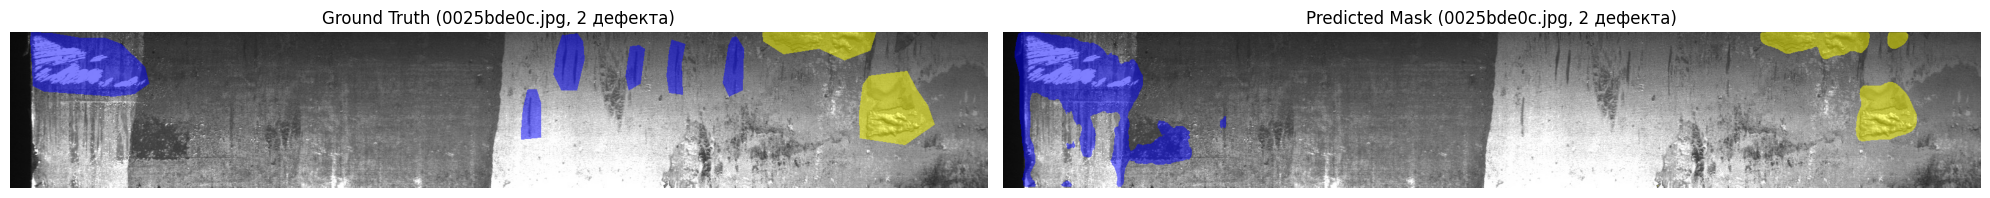

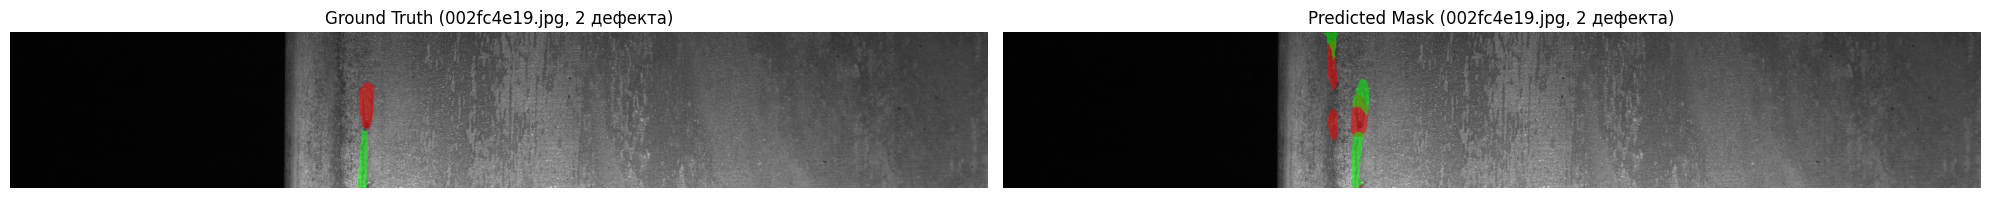

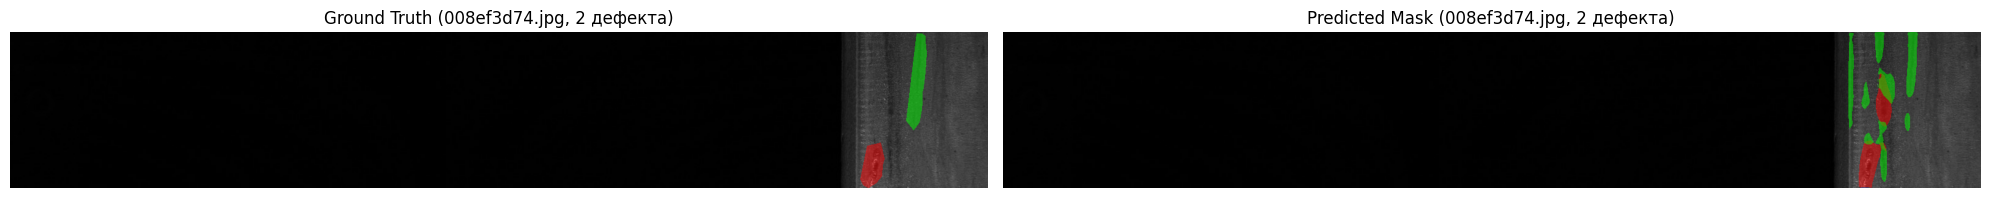

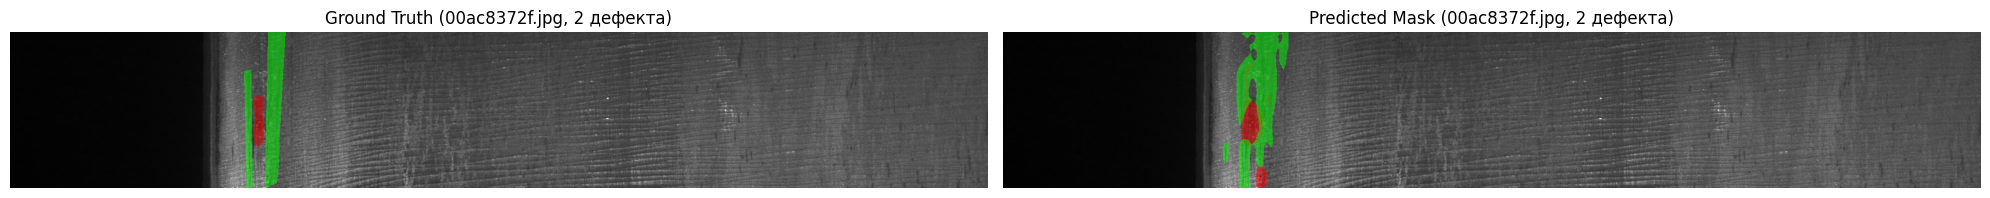

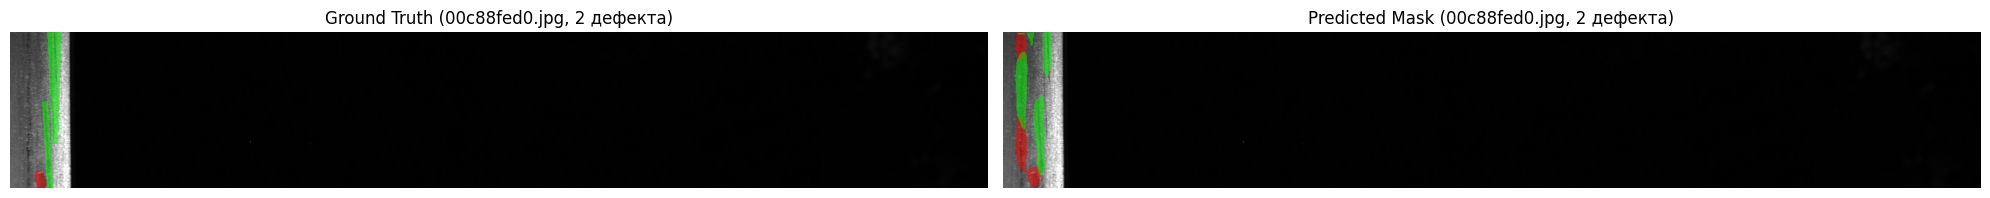

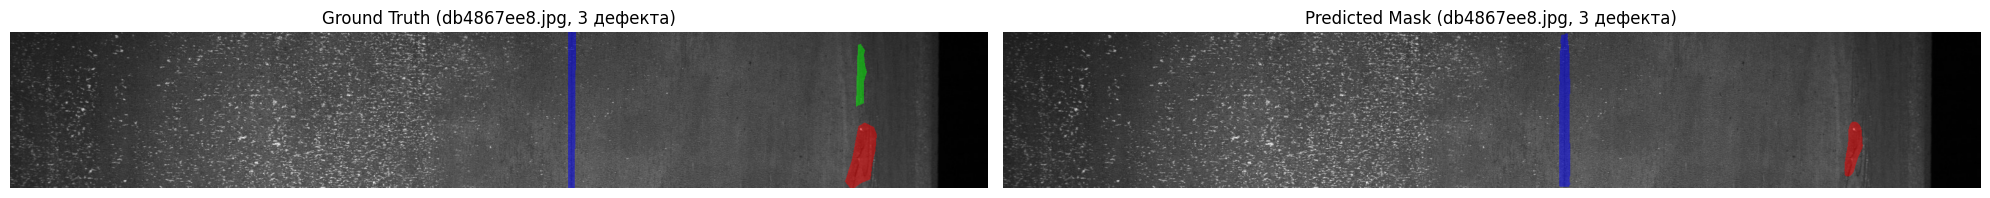

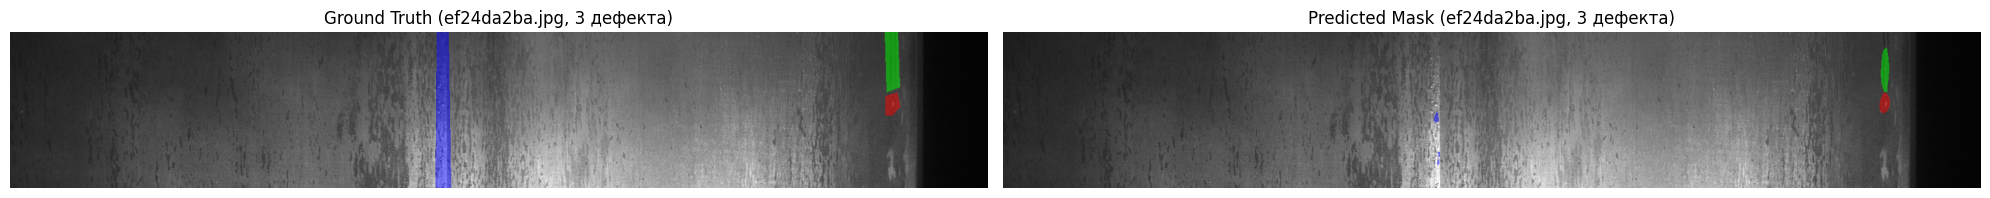

In [ ]:
model.eval()
for defect_count, image_list in images_by_defect_count.items():
    if not image_list:
        continue

    sample_images = image_list[:5]

    for img_id in sample_images:
        img_path = os.path.join(train_folder, img_id)
        img = np.array(Image.open(img_path).convert('RGB'))
        # unsqueeze, чтобы добавить размерность и передать в модель в виде батча из одного изображения (1, c, h, w)
        original_img_tensor = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device)
        ground_truth_masks = encoded_pixels_to_masks(img_id, train_df)

        with torch.no_grad():
            pred = model(original_img_tensor)
            pred_masks_tensor = (torch.sigmoid(pred) > 0.5).float()
            pred_masks_np = pred_masks_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy() # обратно в формат PIL

        fig, axes = plt.subplots(1, 2, figsize=(20, 10))

        show_all_masks(axes[0], img, ground_truth_masks, alpha=0.5,
                       title=f"Ground Truth ({img_id}, {defect_count} дефекта)")

        show_all_masks(axes[1], img, pred_masks_np, alpha=0.5,
                       title=f"Predicted Mask ({img_id}, {defect_count} дефекта)")

        plt.tight_layout()
        plt.show()

Визуализация предсказаний модели для тестовых данных

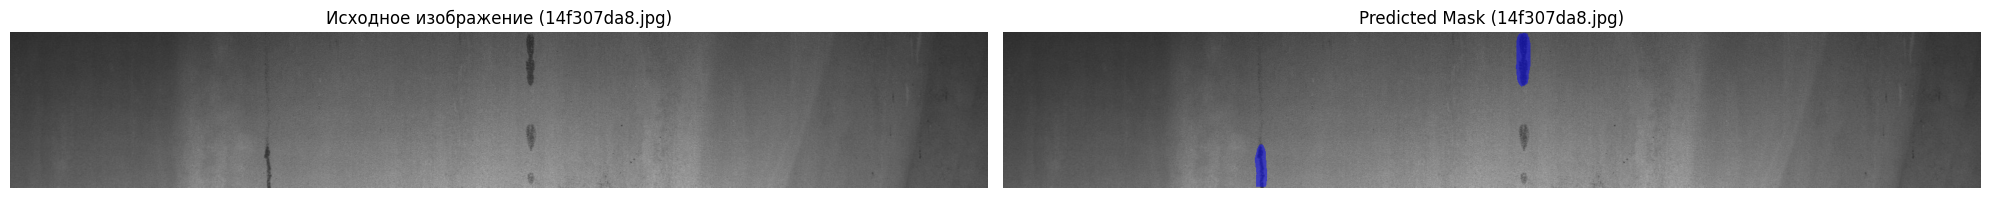

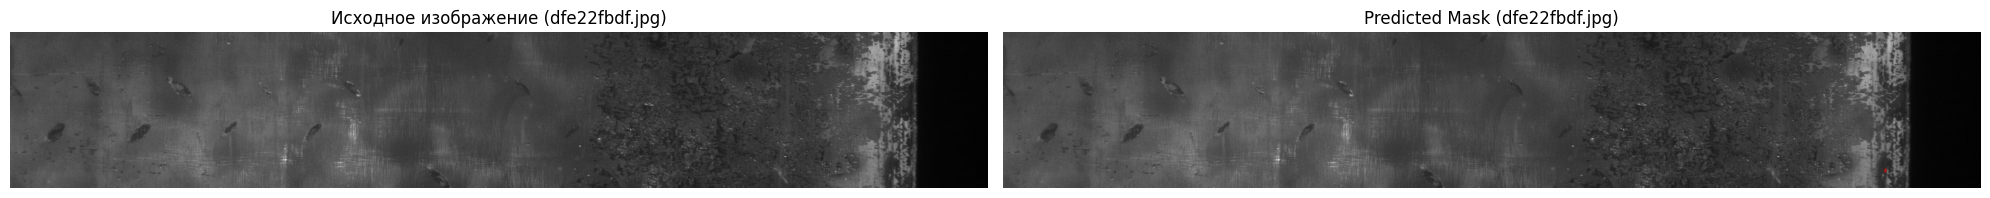

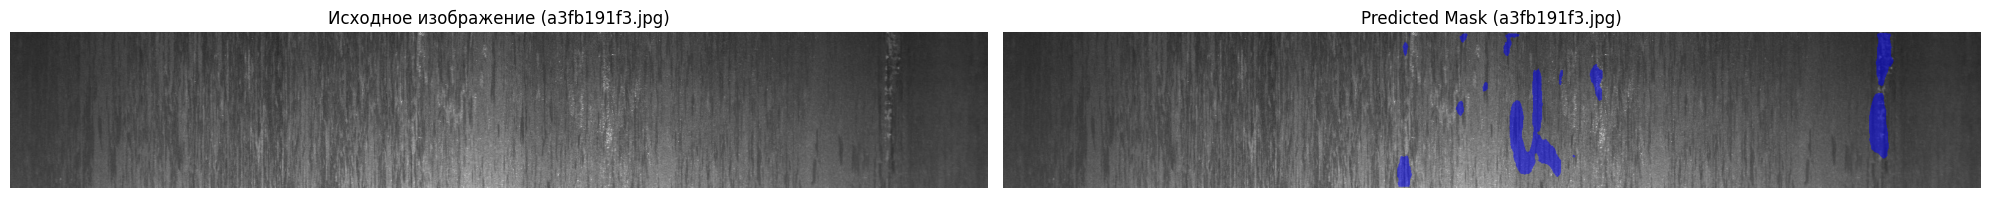

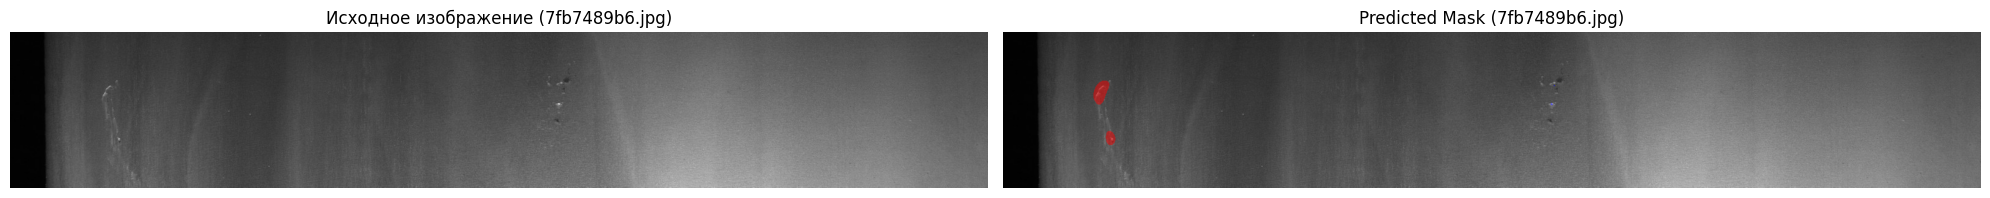

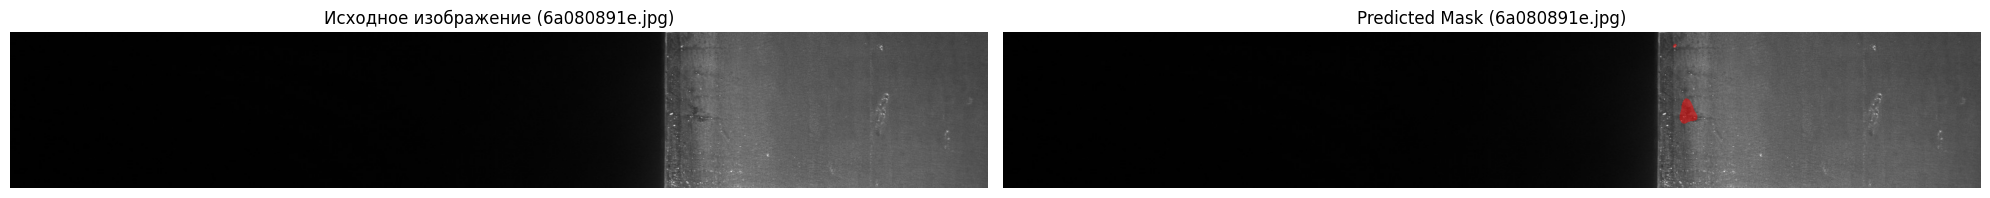

In [ ]:
import random
all_test_images = os.listdir(test_folder)
random_image_ids = random.sample(all_test_images, 5)

for img_id in random_image_ids:
    img_path = os.path.join(test_folder, img_id)
    img = np.array(Image.open(img_path).convert('RGB'))

    original_img_tensor = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(original_img_tensor)
        pred_masks_tensor = (torch.sigmoid(pred) > 0.5).float()
        pred_masks_np = pred_masks_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(20, 10))

    axes[0].imshow(img)
    axes[0].set_title(f"Исходное изображение ({img_id})")
    axes[0].axis('off')

    show_all_masks(axes[1], img, pred_masks_np, alpha=0.5,
                   title=f"Predicted Mask ({img_id})")

    plt.tight_layout()
    plt.show()

Версия №2: RandomCrop 256x512 поменяла на 224x1568 (по 9 эпохам средний dice на валидационной выборке: 0.679). В сравнении, без агументации, по 20 эпохам dice 0.82.

In [ ]:
def load_data(train_val_csv, test_csv, train_val_img_dir, test_img_dir, max_samples=None):
    train_val_df = pd.read_csv(train_val_csv)
    train_val_fnames = pd.unique(train_val_df.ImageId)
    test_df = pd.read_csv(test_csv)
    test_fnames = pd.unique(test_df.ImageId)

    train_fnames, val_fnames = train_test_split(train_val_fnames, test_size=0.2, random_state=42)
    if max_samples:
        train_fnames = train_fnames[:max_samples]
        val_fnames = val_fnames[:max_samples]
        test_fnames = test_fnames[:max_samples]

    transform_pipeline = A.Compose([
        A.RandomCrop(height=224, width=1568, p=1.0),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),])

    train_dataset = SeverstalSteelDataset(train_fnames, train_val_df, train_val_img_dir, transform=transform_pipeline)
    val_dataset = SeverstalSteelDataset(val_fnames, train_val_df, train_val_img_dir)
    test_dataset = SeverstalSteelDataset(test_fnames, test_df, test_img_dir)

    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)#, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)#, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)#, num_workers=2)

    return train_loader, val_loader, test_loader

In [ ]:
train_loader, val_loader, test_loader = load_data(train_csv, test_csv, train_folder, test_folder)

In [ ]:
num_epoches = 30
model, criterion, optimizer = init_model()
final_model = train(model, criterion, optimizer, train_loader, val_loader, epochs=num_epoches)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Epoch 1/30
--------------------------------------------------
loss: 0.6120 | [    0/  667]
loss: 0.4338 | [   10/  667]
loss: 0.4093 | [   20/  667]
loss: 0.3678 | [   30/  667]
loss: 0.7555 | [   40/  667]
loss: 0.4252 | [   50/  667]
loss: 0.4091 | [   60/  667]
loss: 0.2201 | [   70/  667]
loss: 0.2126 | [   80/  667]
loss: 0.2015 | [   90/  667]
loss: 0.3685 | [  100/  667]
loss: 0.4878 | [  110/  667]
loss: 0.3503 | [  120/  667]
loss: 0.3465 | [  130/  667]
loss: 0.2564 | [  140/  667]
loss: 0.4624 | [  150/  667]
loss: 0.3305 | [  160/  667]
loss: 0.2342 | [  170/  667]
loss: 0.5380 | [  180/  667]
loss: 0.3158 | [  190/  667]
loss: 0.2206 | [  200/  667]
loss: 0.3068 | [  210/  667]
loss: 0.2957 | [  220/  667]
loss: 0.3021 | [  230/  667]
loss: 0.1990 | [  240/  667]
loss: 0.2065 | [  250/  667]
loss: 0.1949 | [  260/  667]
loss: 0.1947 | [  270/  667]
loss: 0.1900 | [  280/  667]
loss: 0.1873 | [  290/  667]
loss: 0.4043 | [  300/  667]
loss: 0.1814 | [  310/  667]
loss: 0.48

Продолжение обучения от последней эпохи

In [ ]:
def train(model, criterion, optimizer, train_loader, val_loader, epochs, start_epoch=0, history=None):
    if history is None:
        history = {'train_loss': [], 'val_avg_dice': [], 'epoch': [], 'class_avg_dices': []}

    num_batches = len(train_loader)

    for epoch in range(start_epoch, start_epoch + epochs):
        print(f"Epoch {epoch+1}")
        print("-" * 50)

        model.train()
        epoch_start_time = time.time()
        train_loss = 0

        for i, (filenames, images, masks) in enumerate(train_loader):
            pred = model(images)
            loss = criterion(pred, masks)

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            train_loss += loss.item()

            if i % 10 == 0 or i == num_batches - 1:
                print(f"loss: {loss.item():.4f} | [{i:>5d}/{num_batches:>5d}]")

        avg_train_loss = train_loss / num_batches

        avg_dice, class_avg_dices = evaluate(model, val_loader)
        print(f"Summary:")
        print(f"train avg loss: {avg_train_loss:>4f}, val avg dice: {avg_dice:>0.4f}", end=" ")
        print()
        for class_i, dice_score in enumerate(class_avg_dices):
            print(f"сlass {class_i} dice: {dice_score:>0.4f}")
        print()
        print(f"time spent for epoch: {time.time() - epoch_start_time:.2f} seconds")

        history['train_loss'].append(avg_train_loss)
        history['val_avg_dice'].append(avg_dice)
        history['class_avg_dices'].append(class_avg_dices)
        history['epoch'].append(epoch + 1)

        torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': avg_train_loss,
                'val_avg_dice': avg_dice,
                'class_avg_dices': class_avg_dices,
            }, f'/content/drive/MyDrive/DL_HSE_2025_fall/homeworks/hw2/data/model_epoch_{epoch}_{time.time()}.pth')

    return model, history

In [ ]:
train_loader, val_loader, test_loader = load_data(train_csv, test_csv, train_folder, test_folder)
model_path = '/content/drive/MyDrive/DL_HSE_2025_fall/homeworks/hw2/data/model_epoch_2_1759176555.811611.pth'
checkpoint = torch.load(model_path, map_location=device, weights_only=False)

model = SegModel().to(device)
criterion = SeverstalSteelLoss(bce_weight=0.5, dice_weight=0.5, class_weights=[0.17, 0.61, 0.03, 0.19])
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
last_epoch = checkpoint['epoch']

history = {
    'train_loss': [checkpoint.get('train_loss', 0)],
    'val_avg_dice': [checkpoint.get('val_avg_dice', 0)],
    'class_avg_dices': [checkpoint.get('class_avg_dices', [0, 0, 0, 0])],
    'epoch': [last_epoch + 1]
}

In [ ]:
print(f"Продолжение обучения с эпохи {last_epoch + 1}")

num_epochs_total = 30
remaining_epochs = num_epochs_total - (last_epoch + 1)

final_model, history = train(model, criterion, optimizer, train_loader, val_loader,
                            epochs=remaining_epochs, start_epoch=last_epoch+1, history=history)

Продолжение обучения с эпохи 3
Epoch 4
--------------------------------------------------
loss: 0.0092 | [    0/  667]
loss: 0.1136 | [   10/  667]
loss: 0.0915 | [   20/  667]
loss: 0.1473 | [   30/  667]
loss: 0.3534 | [   40/  667]
loss: 0.3613 | [   50/  667]
loss: 0.0964 | [   60/  667]
loss: 0.1849 | [   70/  667]
loss: 0.1014 | [   80/  667]
loss: 0.3605 | [   90/  667]
loss: 0.0118 | [  100/  667]
loss: 0.1238 | [  110/  667]
loss: 0.1196 | [  120/  667]
loss: 0.0923 | [  130/  667]
loss: 0.1940 | [  140/  667]
loss: 0.1640 | [  150/  667]
loss: 0.0985 | [  160/  667]
loss: 0.0939 | [  170/  667]
loss: 0.0152 | [  180/  667]
loss: 0.1302 | [  190/  667]
loss: 0.1231 | [  200/  667]
loss: 0.0998 | [  210/  667]
loss: 0.1172 | [  220/  667]
loss: 0.0987 | [  230/  667]
loss: 0.4029 | [  240/  667]
loss: 0.1736 | [  250/  667]
loss: 0.4021 | [  260/  667]
loss: 0.0937 | [  270/  667]
loss: 0.1174 | [  280/  667]
loss: 0.1229 | [  290/  667]
loss: 0.1238 | [  300/  667]
loss: 0.116

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.plot(history['epoch'], history['val_avg_dice'], 'b-', label='Validation Avg Dice')
plt.xlabel('Epoch')
plt.ylabel('Avg Dice')
plt.title('Validation Avg Dice')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(history['epoch'], history['train_loss'], 'r-', label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 3)
num_classes = len(history['class_avg_dices'][0])
colors = ['red', 'blue', 'green', 'orange']

for class_idx in range(num_classes):
    class_dices = [epoch_dices[class_idx] for epoch_dices in history['class_avg_dices']]
    plt.plot(history['epoch'], class_dices,
            color=colors[class_idx % len(colors)],
            label=f'Class {class_idx}',
            marker='o', markersize=2)

plt.xlabel('Epoch')
plt.ylabel('Dice Score')
plt.title('Dice Score for Each Class')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined